In [18]:
from hydra import compose, initialize
from omegaconf import OmegaConf

with initialize(config_path="dev/whole_body_benchmark/configs"):
    cfg = compose(config_name="config")

print(OmegaConf.to_yaml(cfg))

/tmp/ipykernel_131002/912625114.py:4: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="dev/whole_body_benchmark/configs"):


paths:
  nako_dir: /nfs/data/nii/data0/GNC/GNC_759
  nnUNet_dir: /nfs/data/nii/data0/GNC/Analysis/GNC_759/ANALYSIS_whole_body_benchmark/nnUNet/
  results_dir: /nfs/data/nii/data0/GNC/Analysis/GNC_759/ANALYSIS_whole_body_benchmark/results/



In [ ]:
# list all subjects that have an image and mask
from pathlib import Path
import glob
import os
img_base_path = Path(cfg.paths.nako_dir) / "links"
mask_base_path = Path(cfg.paths.nako_dir) / "data"
img_target = "30/3D_GRE_TRA_4/3D_GRE_TRA_W_COMPOSE*_s*.nii"
mask_target = "30/opportunistic-screening/seg.nii.gz"
subjects = [e.name for e in os.scandir(img_base_path) if e.is_dir()]
subjects_with_mask = []
for subject in subjects:
    mask_path = os.path.join(mask_base_path, subject, mask_target)
    if os.path.exists(mask_path):
        subjects_with_mask.append(subject)
print(f"subjects with image : {len(subjects)}")
print(f"subjects with image and mask : {len(subjects_with_mask)}")

In [6]:
import nibabel as nib
import numpy as np
from multiprocessing import Pool

def get_labels(subject):
    mask_path = os.path.join(mask_base_path, subject, mask_target)
    mask = nib.load(mask_path)
    mask_data = mask.get_fdata()
    return subject, np.unique(mask_data)

with Pool(12) as pool:
    results = pool.map(get_labels, subjects_with_mask)

labels_by_subject = dict(results)

In [8]:
# filter subjects that have all labels (len=26)
required_labels = set(range(1, 26))
final_subjects = [subject for subject, labels in labels_by_subject.items() if set(labels) >= required_labels]
print(f"subjects with all required labels: {len(final_subjects)}")

subjects with all required labels: 100


In [10]:
# in final_subjects, check which ones have a wholebody/subsetFW.nii.gz file
final_subjects_with_subset = []
for subject in final_subjects:
    subset_path = os.path.join(mask_base_path, subject, "30/wholebody/subsetFW.nii.gz")
    if os.path.exists(subset_path):
        final_subjects_with_subset.append(subject)
print(f"subjects with all required labels and subsetFW: {len(final_subjects_with_subset)}")

subjects with all required labels and subsetFW: 100


In [16]:
import nibabel as nib
import numpy as np
from multiprocessing import Pool
from nilearn.image import resample_to_img

def dice_per_label(subject):
    seg_path = os.path.join(mask_base_path, subject, "30/opportunistic-screening/seg.nii.gz")
    fw_path  = os.path.join(mask_base_path, subject, "30/wholebody/subsetFW.nii.gz")
    if not os.path.exists(seg_path) or not os.path.exists(fw_path):
        return subject, None

    seg_img = nib.load(seg_path)
    fw_img  = nib.load(fw_path)

    fw_seg_img = nib.Nifti1Image(fw_img.get_fdata()[..., 0], fw_img.affine)
    fw_seg_resampled = resample_to_img(fw_seg_img, seg_img, interpolation="nearest")

    seg = seg_img.get_fdata().astype(int)
    fw  = fw_seg_resampled.get_fdata().astype(int)

    labels = np.unique(np.concatenate([np.unique(seg), np.unique(fw)]))
    labels = labels[labels != 0]

    dice = {}
    for label in labels:
        a = seg == label
        b = fw  == label
        denom = a.sum() + b.sum()
        dice[int(label)] = 2 * np.logical_and(a, b).sum() / denom if denom > 0 else np.nan
    return subject, dice

with Pool(12) as pool:
    results = pool.map(dice_per_label, final_subjects)

dice_by_subject = {s: d for s, d in results if d is not None}
print(f"Computed Dice for {len(dice_by_subject)} subjects")

import pandas as pd
df = pd.DataFrame(dice_by_subject).T
print("\nMean Dice per label:")
print(df.mean().sort_index())

/tmp/ipykernel_131002/2602134642.py:16: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  fw_seg_resampled = resample_to_img(fw_seg_img, seg_img, interpolation="nearest")
/tmp/ipykernel_131002/2602134642.py:16: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  fw_seg_resampled = resample_to_img(fw_seg_img, seg_img, interpolation="nearest")
/tmp/ipykernel_131002/2602134642.py:16: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  fw_seg_resampled = resample_to_img(fw_seg_img, seg_img, interpolation="nearest")
/tmp/ipykernel_131002/2602134642.py:16: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  fw_seg_resampled = resample_to_img(fw_seg_img

Computed Dice for 100 subjects

Mean Dice per label:
1     0.953493
2     0.875419
3     0.953396
4     0.938219
5     0.934800
6     0.744897
7     0.929590
8     0.938652
9     0.929946
10    0.670732
11    0.941041
12    0.194243
13    0.953025
14    0.864202
15    0.915268
16    0.812305
17    0.970851
18    0.908310
19    0.927663
20    0.910234
21    0.907912
22    0.799262
23    0.916707
24    0.907277
25    0.840814
dtype: float64


/tmp/ipykernel_131002/2999609043.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[col].dropna() for col in df.columns], labels=df.columns, patch_artist=True)


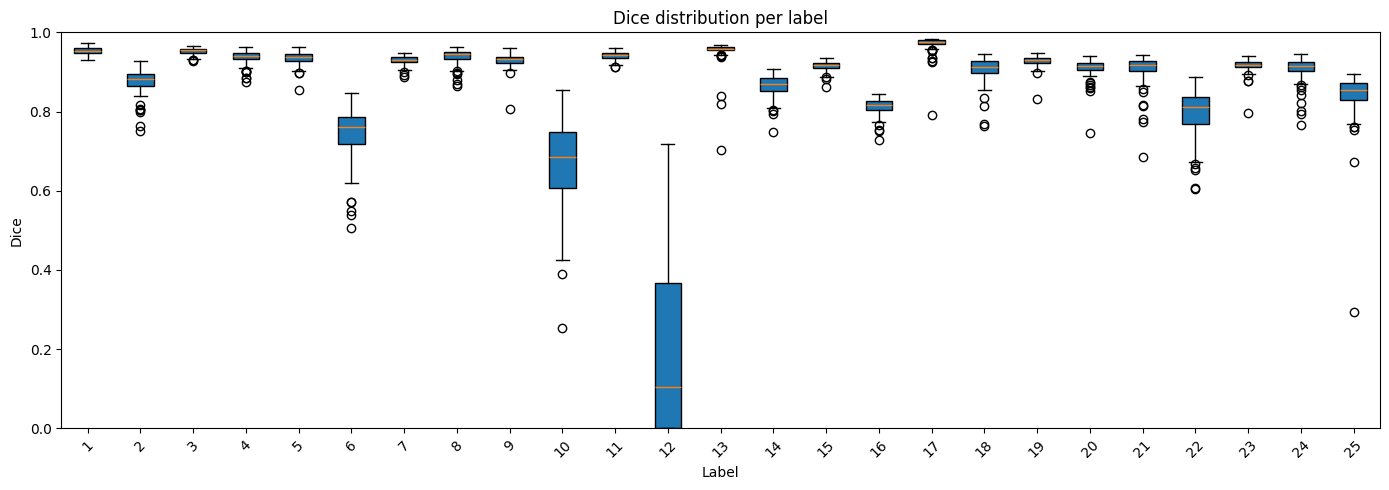

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(dice_by_subject).T.sort_index(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot([df[col].dropna() for col in df.columns], labels=df.columns, patch_artist=True)
ax.set_xlabel('Label')
ax.set_ylabel('Dice')
ax.set_title('Dice distribution per label')
ax.set_ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [20]:
import random

random.seed(42)
shuffled = final_subjects.copy()
random.shuffle(shuffled)
split = int(0.7 * len(shuffled))
splits = {'train': shuffled[:split], 'test': shuffled[split:]}
print(f"train: {len(splits['train'])}, test: {len(splits['test'])}")


train: 70, test: 30


In [21]:
import json
from pathlib import Path

out_path = Path(cfg.paths.results_dir) / 'splits.json'
with open(out_path, 'w') as f:
    json.dump(splits, f)
print(f'Saved to {out_path}')


Saved to /nfs/data/nii/data0/GNC/Analysis/GNC_759/ANALYSIS_whole_body_benchmark/results/splits.json
